# Task 2: Evaluating Chaotic systems

We will use one chaotic system: **Lorenz system**.

Then we evaluate it using:

1. **Phase Space Reconstruction (PSR)**
   - Time delay using AMI
   - Embedding dimension using FNN

2. **Lyapunov Exponent**
   - From the ODE directly
   - From scalar time series

3. **Correlation Dimension**
   - Estimate the fractal dimension using pair distances

4. **K2 Entropy**
   - Estimate information production 

5. **Box-Counting Dimension**
   - Estimate another fractal dimension by counting occupied boxes

In [ ]:
#imports and libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.spatial.distance import pdist

from psr import (
    AMIConfig,
    FNNConfig,
    estimate_delay_ami,
    estimate_dimension_fnn,
    reconstruct_matrix,
)

from lyapunov import (
    AttractorODEConfig,
    WolfODEConfig,
    WolfConfig,
    lyapunov_wolf_ode,
    wolf_mle,
)

FIG_DIR = Path("task2_figures")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.precision", 5)

print("Imports successful.")
print("Figures will be saved in:", FIG_DIR)

Imports successful.
Figures will be saved in: task2_figures


## Part A: Phase Space Reconstruction (PSR)

### A.1 Generating Lorenz system

In [2]:
def lorenz_ode(state, t, sigma, rho, beta):

    x, y, z = state
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ], dtype=float)


def lorenz_jacobian(state, t, sigma, rho, beta):

    x, y, z = state
    return np.array([
        [-sigma, sigma, 0.0],
        [rho - z, -1.0, -x],
        [y, x, -beta],
    ], dtype=float)


def rk4_integrate_ode(ode_func, x0, params, dt, n_steps):

    states = np.empty((n_steps + 1, len(x0)), dtype=float)
    times = np.empty(n_steps + 1, dtype=float)

    state = np.asarray(x0, dtype=float)
    current_t = 0.0
    states[0] = state
    times[0] = current_t

    for i in range(n_steps):
        k1 = ode_func(state, current_t, *params)
        k2 = ode_func(state + 0.5 * dt * k1, current_t + 0.5 * dt, *params)
        k3 = ode_func(state + 0.5 * dt * k2, current_t + 0.5 * dt, *params)
        k4 = ode_func(state + dt * k3, current_t + dt, *params)

        state = state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        current_t += dt

        states[i + 1] = state
        times[i + 1] = current_t

    return times, states

In [3]:
# Lorenz parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
params = (sigma, rho, beta)

# Sim settings
x0 = np.array([1.0, 1.0, 1.0])
dt = 0.01
transient_steps = 5_000
kept_steps = 15_000
n_steps = transient_steps + kept_steps

# Simulate
t_all, states_all = rk4_integrate_ode(
    ode_func=lorenz_ode,
    x0=x0,
    params=params,
    dt=dt,
    n_steps=n_steps,
)

# Remove transient
t = t_all[transient_steps:] - t_all[transient_steps]
states = states_all[transient_steps:]
x_series = states[:, 0]
y_series = states[:, 1]
z_series = states[:, 2]

print("Total simulated points:", len(t_all))
print("Points after transient:", len(t))
print("Scalar series used for PSR:", x_series.shape)

Total simulated points: 20001
Points after transient: 15001
Scalar series used for PSR: (15001,)


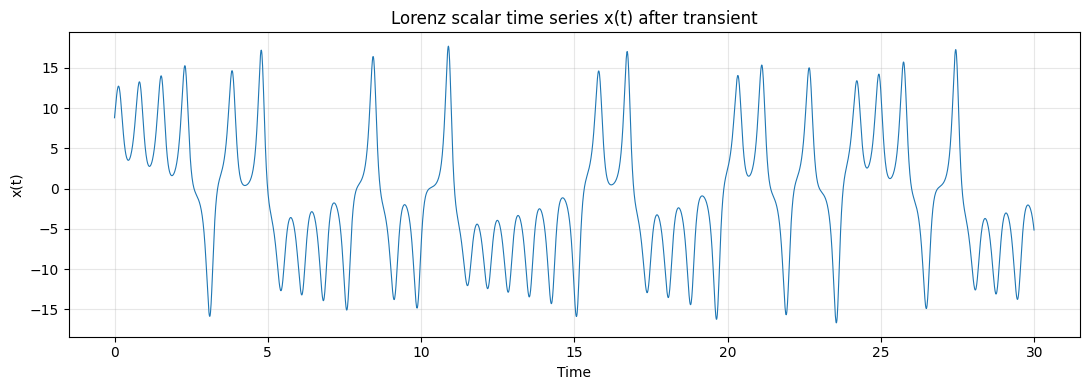

In [4]:
# Plot x(t)
plt.figure(figsize=(11, 4))
plt.plot(t[:3000], x_series[:3000], linewidth=0.8)
plt.title("Lorenz scalar time series x(t) after transient")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz_x_time_series.png", bbox_inches="tight")
plt.show()

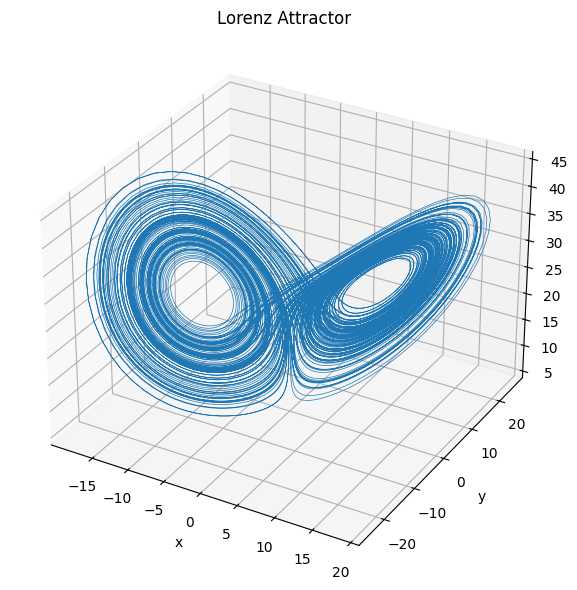

In [5]:
# Plot Lorenz 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

stride = max(1, len(states) // 8000)
ax.plot(states[::stride, 0], states[::stride, 1], states[::stride, 2], linewidth=0.5)

ax.set_title("Lorenz Attractor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz_attractor_3d.png", bbox_inches="tight")
plt.show()

### 1.2 Phase Space Reconstruction (PSR)

In [6]:
# Time delay using AMI

ami_cfg = AMIConfig(
    max_lag=120,
    n_bins=32,
    criterion="first_local_min",
)

tau_opt, lags, ami_vals = estimate_delay_ami(
    x_series,
    cfg=ami_cfg,
    standardize=True,
)

print("Optimal time delay tau:", tau_opt)

Optimal time delay tau: 16


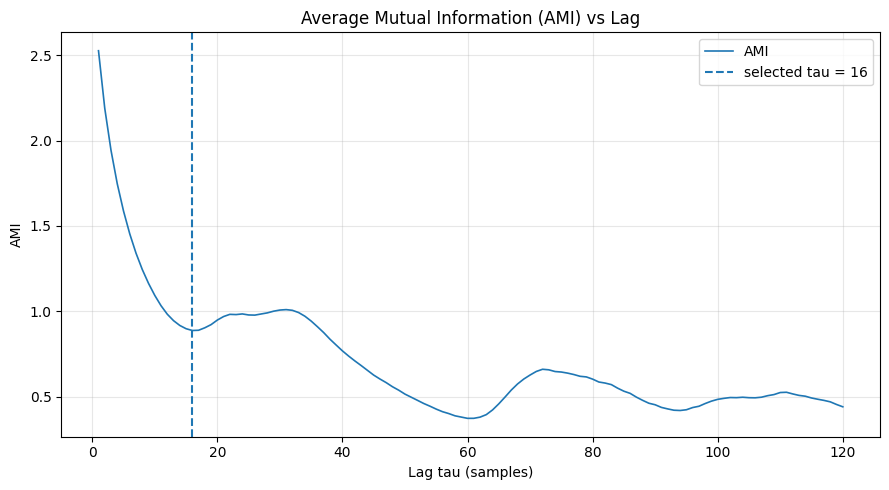

In [7]:
# plot AMI vs Lag
plt.figure(figsize=(9, 5))
plt.plot(lags, ami_vals, linewidth=1.2, label="AMI")
plt.axvline(tau_opt, linestyle="--", label=f"selected tau = {tau_opt}")

plt.title("Average Mutual Information (AMI) vs Lag")
plt.xlabel("Lag tau (samples)")
plt.ylabel("AMI")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "partA_ami_delay.png", bbox_inches="tight")
plt.show()

In [8]:
# Embedding dimension using False Nearest Neighbors (FNN)

fnn_theiler = max(50, tau_opt * 3)

fnn_cfg = FNNConfig(
    max_dim=10,
    R_tol=10.0,
    A_tol=2.0,
    threshold_percent=1.0,
    theiler=fnn_theiler,
    distance_metric="euclidean",
)

m_opt, dims, fnn_pct = estimate_dimension_fnn(
    x_series,
    tau=tau_opt,
    cfg=fnn_cfg,
    standardize=True,
)

print("Optimal embedding dimension m:", m_opt)
print("Theiler window used:", fnn_theiler)

Optimal embedding dimension m: 3
Theiler window used: 50


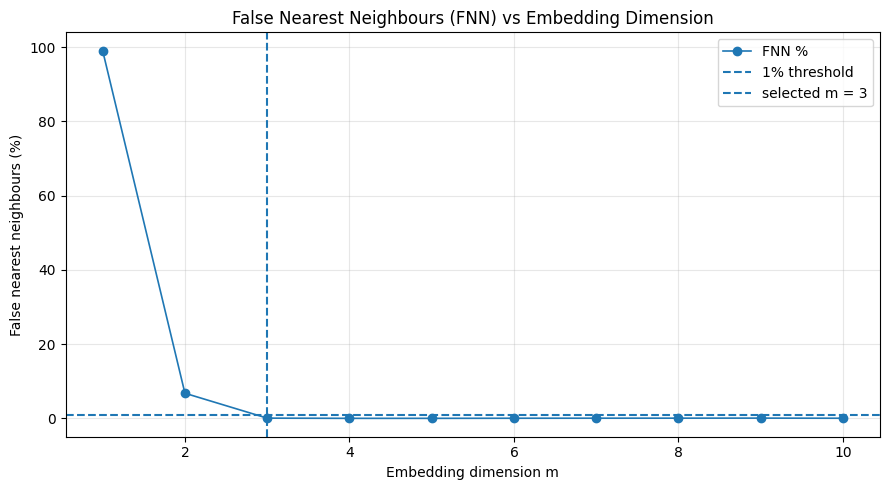

In [9]:
# plot FNN % vs Embedding Dimension
plt.figure(figsize=(9, 5))
plt.plot(dims, fnn_pct, marker="o", linewidth=1.2, label="FNN %")
plt.axhline(fnn_cfg.threshold_percent, linestyle="--", label="1% threshold")
plt.axvline(m_opt, linestyle="--", label=f"selected m = {m_opt}")

plt.title("False Nearest Neighbours (FNN) vs Embedding Dimension")
plt.xlabel("Embedding dimension m")
plt.ylabel("False nearest neighbours (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "partA_fnn_dimension.png", bbox_inches="tight")
plt.show()

In [10]:
psr_results = pd.DataFrame({
    "Quantity": ["Selected delay tau", "Selected embedding dimension m"],
    "Value": [tau_opt, m_opt],
})

psr_results

,Quantity,Value
0,Selected delay tau,16
1,Selected embedding dimension m,3


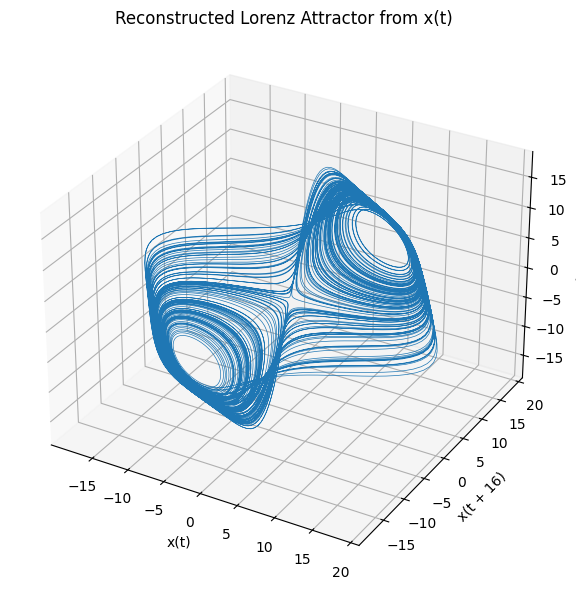

In [11]:
# Reconstruct the phase space using tau and m.
X_reconstructed = reconstruct_matrix(x_series, tau=tau_opt, d=m_opt)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Constrict coordinates to 3 dim if (m > 3)
ax.plot(
    X_reconstructed[::stride, 0],
    X_reconstructed[::stride, 1],
    X_reconstructed[::stride, 2],
    linewidth=0.5,
)
ax.set_xlabel("x(t)")
ax.set_ylabel(f"x(t + {tau_opt})")
ax.set_zlabel(f"x(t + {2*tau_opt})")


ax.set_title("Reconstructed Lorenz Attractor from x(t)")
plt.tight_layout()
plt.savefig(FIG_DIR / "partA_reconstructed_attractor.png", bbox_inches="tight")
plt.show()

The reconstructed attractor doesn't look exactly like the original (x, y, z). But the most important thing is that it caught the same underlying structure of the original (two circular regions) using only x(t)

## Part B: Lyapunov Exponent

### B.1: Lyapunov spectrum from the ODE directly

In [12]:
# Lyapunov spectrum from ODE

ode_lyap_cfg = AttractorODEConfig(
    ode=lorenz_ode,
    jacobian=lorenz_jacobian,
    x0=x0.copy(),
    params=params,
    dt=dt,
    transient_steps=2_000,
    n_steps=30_000,
    solver=None,  # fixed-step RK4
)

wolf_ode_cfg = WolfODEConfig(
    ortho_steps=20,
    log_base="e",  # nats/time
)

lyap_spectrum_nats = lyapunov_wolf_ode(
    attractor_cfg=ode_lyap_cfg,
    wolf_cfg=wolf_ode_cfg,
)

# Convert to bits/time
lyap_spectrum_bits = lyap_spectrum_nats / np.log(2.0)

print("Lyapunov spectrum from ODE, nats/time:")
print(lyap_spectrum_nats)

print("\nLyapunov spectrum from ODE, bits/time:")
print(lyap_spectrum_bits)

Lyapunov spectrum from ODE, nats/time:
[ 8.97504725e-01 -2.63695503e-03 -1.45614329e+01]

Lyapunov spectrum from ODE, bits/time:
[ 1.29482562e+00 -3.80432195e-03 -2.10077070e+01]


### B.2: Lyapunov exponent from scalar time-series

In [ ]:
# Largest Lyapunov exponent from scalar time series

wolf_ts_cfg = WolfConfig(
    theiler_window=max(tau_opt * m_opt, 50),
    min_dist_scale=1e-3,
    max_dist_scale=1e-1,
    evolve_cap=50,
    max_replacements=200,
    angle_weight=0.3,
)

mle_bits_mopt, mle_debug_mopt = wolf_mle(
    x_series,
    dt=dt,
    tau=tau_opt,
    m=m_opt,
    cfg=wolf_ts_cfg,
    return_debug=True,
)

mle_nats_mopt = mle_bits_mopt * np.log(2.0)

print(f"Time-series LLE using m_opt = {m_opt}:")
print(f"lambda1 = {mle_bits_mopt:.5f} bits/time")
print(f"lambda1 = {mle_nats_mopt:.5f} nats/time")
print("Tracked segments:", mle_debug_mopt["replacements"])
print("Physical time used:", mle_debug_mopt["physical_time_used"])

Time-series LLE using m_opt = 3:
lambda1 = 2.41989 bits/time
lambda1 = 1.67734 nats/time
Tracked segments: 200
Physical time used: 99.78


In [16]:
lyapunov_comparison = pd.DataFrame({
    "Method": [
        "ODE Wolf-GSR",
        f"Time-series Wolf using m_opt={m_opt}",
    ],
    "Reported value": [
        lyap_spectrum_bits[0],
        mle_bits_mopt,
    ],
    "Units": [
        "bits/time",
        "bits/time",
    ],
    "Notes": [
        "Full spectrum method using equations and Jacobian",
        "Scalar x(t) only; depends on PSR and tracking settings",
    ],
})

lyapunov_comparison

,Method,Reported value,Units,Notes
0,ODE Wolf-GSR,1.29483,bits/time,Full spectrum method using equations and Jacobian
1,Time-series Wolf using m_opt=3,2.41989,bits/time,Scalar x(t) only; depends on PSR and tracking ...


## Part D: Correlation Dimension
I will be doing part D before part C because K2 entropy uses correlation sum from part D

In [17]:
def standardize_series(x):
    return (x - np.mean(x)) / np.std(x)


def correlation_sums_for_embedding(x, tau, dim, radii, theiler=0, max_points=2200):
    
    x_std = standardize_series(x)
    X = reconstruct_matrix(x_std, tau=tau, d=dim)
    N = len(X)

    if N > max_points:
        selected = np.linspace(0, N - 1, max_points, dtype=int)
        X_sample = X[selected]
        original_indices = selected
    else:
        X_sample = X
        original_indices = np.arange(N)

    i_idx, j_idx = np.triu_indices(len(X_sample), k=1)

    # Theiler exclusion: remove temporally close points.
    valid_pairs = np.abs(original_indices[i_idx] - original_indices[j_idx]) > theiler
    i_valid = i_idx[valid_pairs]
    j_valid = j_idx[valid_pairs]

    differences = X_sample[i_valid] - X_sample[j_valid]
    distances = np.sqrt(np.sum(differences * differences, axis=1))

    C = np.array([(distances < r).mean() for r in radii])

    return C, len(X_sample), len(distances)


def slope_in_scaling_region(log_r, log_C, scaling_indices):

    idx = np.asarray(scaling_indices)
    valid = np.isfinite(log_C[idx])
    selected_idx = idx[valid]
    if len(selected_idx) < 2:
        return np.nan
    return np.polyfit(log_r[selected_idx], log_C[selected_idx], 1)[0]

In [18]:
# Define radii from a sample of the reconstructed attractor.

x_std = standardize_series(x_series)
X_ref = reconstruct_matrix(x_std, tau=tau_opt, d=m_opt)

sample_for_scale = X_ref[np.linspace(0, len(X_ref) - 1, min(1000, len(X_ref)), dtype=int)]
sample_distances = pdist(sample_for_scale)

r_min = np.percentile(sample_distances, 1)
r_max = np.percentile(sample_distances, 50)
radii = np.logspace(np.log10(r_min), np.log10(r_max), 30)

# Scaling region chosen by index.
scaling_indices = np.arange(7, 21)

print("Radius min:", r_min)
print("Radius max:", r_max)
print("Number of radii:", len(radii))
print("Scaling region indices:", scaling_indices[0], "to", scaling_indices[-1])

Radius min: 0.20762246792585926
Radius max: 2.0745393492880817
Number of radii: 30
Scaling region indices: 7 to 20


In [19]:
# Compute correlation sums for several embedding dimensions.

embedding_dims_for_d2 = list(range(max(2, m_opt - 1), min(m_opt + 5, 9)))
correlation_results = {}
correlation_rows = []

for dim in embedding_dims_for_d2:
    theiler_dim = max(50, tau_opt * dim)
    C, used_points, valid_pair_count = correlation_sums_for_embedding(
        x_series,
        tau=tau_opt,
        dim=dim,
        radii=radii,
        theiler=theiler_dim,
        max_points=2200,
    )

    log_r = np.log(radii)
    log_C = np.log(np.where(C > 0, C, np.nan))
    D2 = slope_in_scaling_region(log_r, log_C, scaling_indices)

    correlation_results[dim] = {
        "C": C,
        "D2": D2,
        "used_points": used_points,
        "valid_pair_count": valid_pair_count,
        "theiler": theiler_dim,
    }

    correlation_rows.append({
        "embedding dimension": dim,
        "D2 estimate": D2,
        "points used": used_points,
        "valid pairs": valid_pair_count,
        "Theiler window": theiler_dim,
    })

correlation_dimension_table = pd.DataFrame(correlation_rows)
correlation_dimension_table

,embedding dimension,D2 estimate,points used,valid pairs,Theiler window
0,2,1.46845,2200,2403528,50
1,3,1.63224,2200,2403528,50
2,4,1.75620,2200,2399145,64
3,5,1.87838,2200,2394766,80
4,6,1.94949,2200,2388205,96
5,7,1.95733,2200,2383836,112


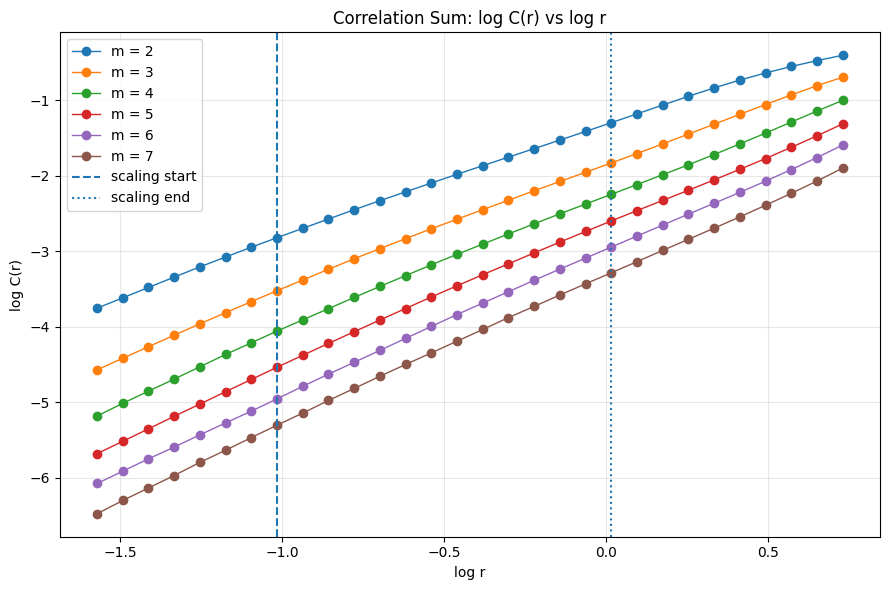

In [20]:
# plot log C(r) vs log r for different embedding dimensions
plt.figure(figsize=(9, 6))

for dim in embedding_dims_for_d2:
    C = correlation_results[dim]["C"]
    plt.plot(np.log(radii), np.log(np.where(C > 0, C, np.nan)), marker="o", linewidth=1.0, label=f"m = {dim}")

plt.axvline(np.log(radii[scaling_indices[0]]), linestyle="--", label="scaling start")
plt.axvline(np.log(radii[scaling_indices[-1]]), linestyle=":", label="scaling end")

plt.title("Correlation Sum: log C(r) vs log r")
plt.xlabel("log r")
plt.ylabel("log C(r)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "partD_logC_logr.png", bbox_inches="tight")
plt.show()

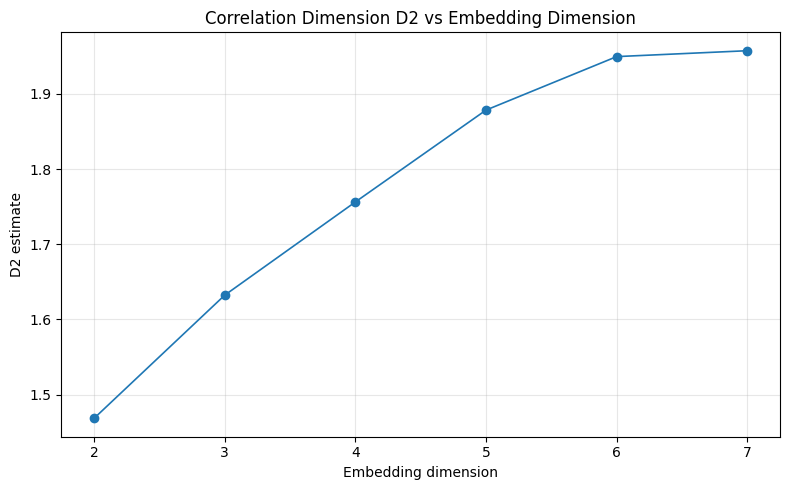

In [21]:
# plot D2 estimate vs embedding dimension
plt.figure(figsize=(8, 5))
plt.plot(
    correlation_dimension_table["embedding dimension"],
    correlation_dimension_table["D2 estimate"],
    marker="o",
    linewidth=1.2,
)

plt.title("Correlation Dimension D2 vs Embedding Dimension")
plt.xlabel("Embedding dimension")
plt.ylabel("D2 estimate")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "partD_D2_vs_embedding_dimension.png", bbox_inches="tight")
plt.show()

In [ ]:
# Use last D2 value as the most stable estimate 
D2_saturated = correlation_dimension_table["D2 estimate"].iloc[-1]
print(f"Approximate saturated D2 estimate: {D2_saturated:.4f}")

Approximate saturated D2 estimate: 1.9573


The correlation dimension increase at first as the embedding dimension increases. After that, they start to change more slowly.
This kind saturation suggests that the Lorenz attractor is low-dimensional and fractal, not random high-dimensional noise.

## Part C: Kolmogorov "K2" Entropy

In [ ]:
# Compute K2 estimate from correlation sums.
k2_rows = []

for dim in embedding_dims_for_d2[:-1]:
    C_m = correlation_results[dim]["C"]
    C_next = correlation_results[dim + 1]["C"]

    valid = (C_m > 0) & (C_next > 0)
    valid_scaling = valid.copy()
    mask_indices = np.zeros_like(valid_scaling, dtype=bool)
    mask_indices[scaling_indices] = True
    valid_scaling = valid_scaling & mask_indices

    K2_values = np.log(C_m[valid_scaling] / C_next[valid_scaling]) / (tau_opt * dt)
    K2_estimate = np.mean(K2_values) if len(K2_values) else np.nan

    k2_rows.append({
        "m to m+1": f"{dim} to {dim+1}",
        "m": dim,
        "K2 estimate": K2_estimate,
        "number of radii used": len(K2_values),
    })

k2_table = pd.DataFrame(k2_rows)
k2_table

,m to m+1,m,K2 estimate,number of radii used
0,2 to 3,2,3.79090,14
1,3 to 4,3,2.96293,14
2,4 to 5,4,2.61774,14
3,5 to 6,5,2.39954,14
4,6 to 7,6,2.16623,14


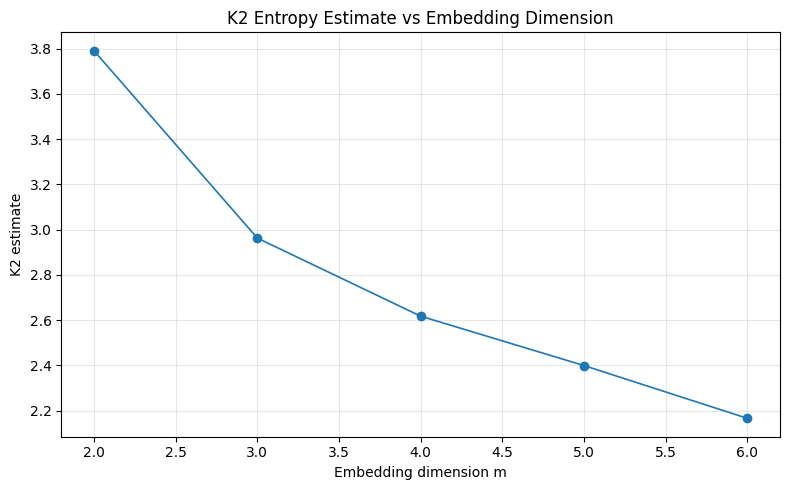

In [24]:
# plot K2 estimate vs embedding dimension
plt.figure(figsize=(8, 5))
plt.plot(k2_table["m"], k2_table["K2 estimate"], marker="o", linewidth=1.2)

plt.title("K2 Entropy Estimate vs Embedding Dimension")
plt.xlabel("Embedding dimension m")
plt.ylabel("K2 estimate")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "partC_K2_vs_embedding_dimension.png", bbox_inches="tight")
plt.show()

In [25]:
K2_final = k2_table["K2 estimate"].iloc[-1]
print(f"Approximate final K2 estimate: {K2_final:.4f}")

Approximate final K2 estimate: 2.1662


The K2 saturates to a finite positive value instead of growing without bound which is an indicator of "low-dimensional chaos"

## Part E: Practal (Box-counting) dimension

In [26]:
def box_counting_dimension(points, epsilons, scaling_indices):

    points = np.asarray(points, dtype=float)

    # Normalize points to [0, 1] in each coordinate.
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    normalized = (points - mins) / (maxs - mins + 1e-12)

    counts = []
    for eps in epsilons:
        box_indices = np.floor(normalized / eps).astype(int)
        occupied_boxes = np.unique(box_indices, axis=0)
        counts.append(len(occupied_boxes))

    counts = np.array(counts)
    log_inv_eps = np.log(1.0 / epsilons)
    log_counts = np.log(counts)

    D0 = np.polyfit(log_inv_eps[scaling_indices], log_counts[scaling_indices], 1)[0]

    return D0, counts, log_inv_eps, log_counts

In [27]:
# Use the original 3D Lorenz attractor points for box-counting (after transient).
box_points = states

epsilons = np.logspace(np.log10(0.5), np.log10(0.01), 22)
box_scaling_indices = np.arange(2, 7)

D0_estimate, box_counts, log_inv_eps, log_counts = box_counting_dimension(
    points=box_points,
    epsilons=epsilons,
    scaling_indices=box_scaling_indices,
)

box_table = pd.DataFrame({
    "epsilon": epsilons,
    "N(epsilon) occupied boxes": box_counts,
    "ln(1/epsilon)": log_inv_eps,
    "ln N(epsilon)": log_counts,
})

print(f"Estimated box-counting dimension D0: {D0_estimate:.4f}")
box_table

Estimated box-counting dimension D0: 2.1041


,epsilon,N(epsilon) occupied boxes,ln(1/epsilon),ln N(epsilon)
0,0.50000,8,0.69315,2.07944
1,0.41502,19,0.87943,2.94444
2,0.34448,17,1.06572,2.83321
3,0.28593,32,1.25201,3.46574
4,0.23733,44,1.43829,3.78419
5,0.19699,63,1.62458,4.14313
6,0.16351,86,1.81087,4.45435
7,0.13572,120,1.99715,4.78749
8,0.11265,156,2.18344,5.04986
9,0.09351,225,2.36973,5.41610


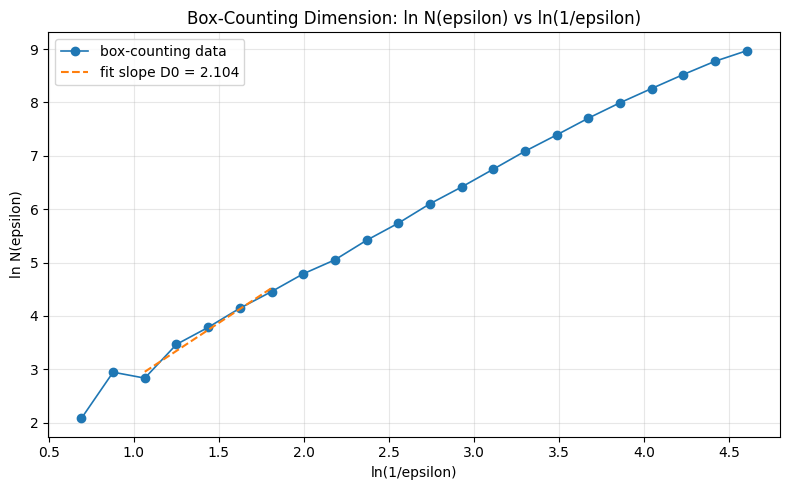

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(log_inv_eps, log_counts, marker="o", linewidth=1.2, label="box-counting data")

# Fitted line in scaling region
fit_coeffs = np.polyfit(log_inv_eps[box_scaling_indices], log_counts[box_scaling_indices], 1)
fit_line = np.polyval(fit_coeffs, log_inv_eps[box_scaling_indices])
plt.plot(log_inv_eps[box_scaling_indices], fit_line, linestyle="--", label=f"fit slope D0 = {D0_estimate:.3f}")

plt.title("Box-Counting Dimension: ln N(epsilon) vs ln(1/epsilon)")
plt.xlabel("ln(1/epsilon)")
plt.ylabel("ln N(epsilon)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "partE_box_counting_dimension.png", bbox_inches="tight")
plt.show()

In [29]:
fractal_comparison = pd.DataFrame({
    "Measure": ["Correlation dimension D2", "Box-counting dimension D0"],
    "Estimate": [D2_saturated, D0_estimate],
    "Meaning": [
        "Based on how pair distances scale",
        "Based on how occupied boxes scale",
    ],
})

fractal_comparison

,Measure,Estimate,Meaning
0,Correlation dimension D2,1.95733,Based on how pair distances scale
1,Box-counting dimension D0,2.10410,Based on how occupied boxes scale
